# Deep Learning Project — Multi-Modal Classification (Flickr8k)

**Dataset** : Flickr8k — 8 000 images, 5 captions par image  
**Pipeline** :
- **Step 1** — Image Processing with CNN (ResNet50) ✅
- **Step 2** — Text Processing with Embeddings and RNN ✅
- **Step 3** — Multi-Modal Fusion 🔲
- **Step 4** — Model Tuning & Optimization ✅

---
# Step 1 — Image Processing with CNN (ResNet50)

**Objectif** : Prétraiter les images Flickr8k et extraire des features visuelles avec ResNet50 pré-entraîné.

Pipeline :
1. Chargement et visualisation des données
2. Prétraitement des images (resize + normalisation)
3. Extraction de features avec ResNet50 (sans la couche finale)
4. Sauvegarde des features pour la fusion multi-modale (Step 3)

## 1.1 Imports et configuration

In [1]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torchvision import models, transforms

# Chemins
DATA_DIR   = '../data/raw/'
IMG_DIR    = os.path.join(DATA_DIR, 'Images')
CAPTIONS_FILE = os.path.join(DATA_DIR, 'captions.txt')
SAVE_DIR   = '../data/processed/'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../models/checkpoints', exist_ok=True)
os.makedirs('../models/pretrained', exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

Device : cpu


## 1.2 Chargement et exploration des données

In [2]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = ['image', 'caption']
print(f'Lignes totales : {len(df)}')
print(f'Images uniques : {df["image"].nunique()}')
df.head()

Lignes totales : 40455
Images uniques : 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


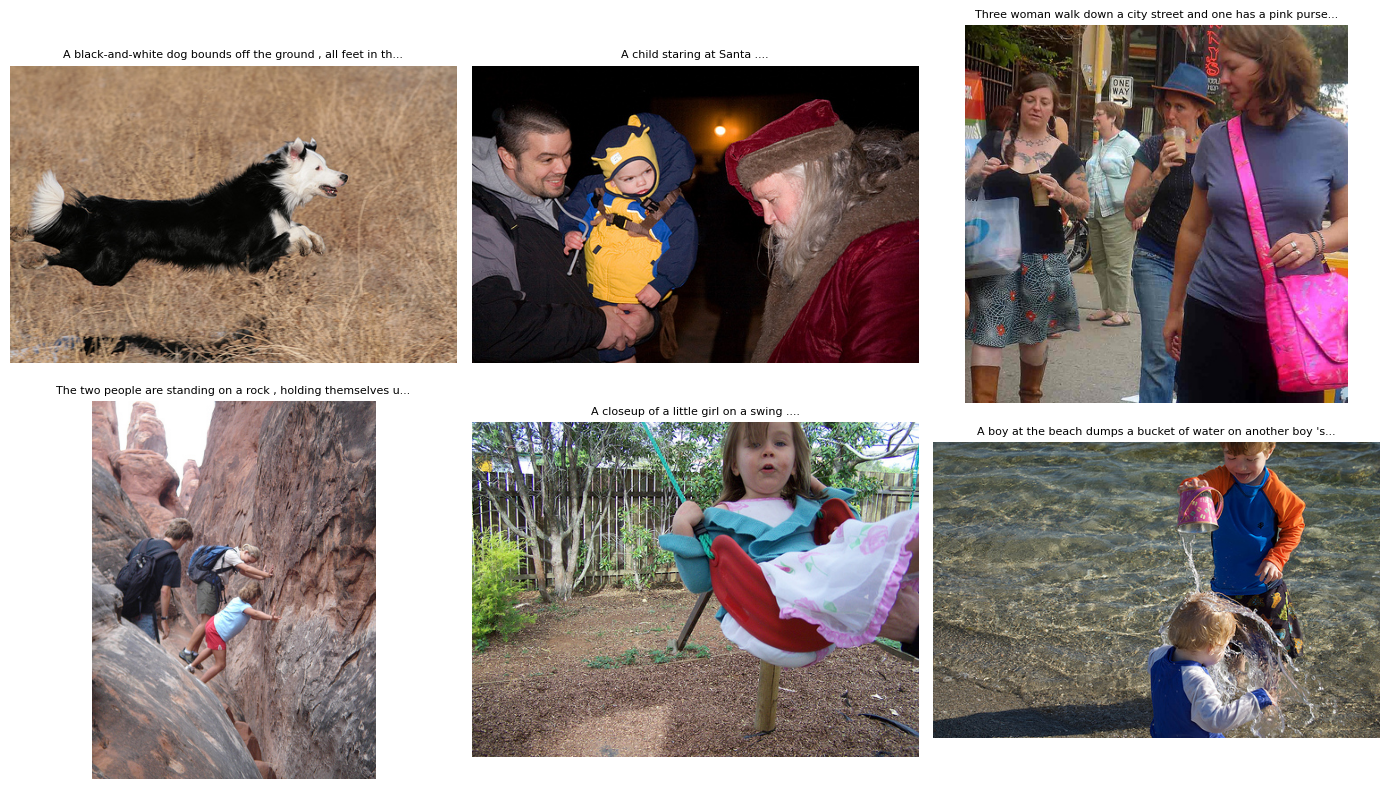

In [3]:
# Visualisation de quelques images avec leurs captions
sample = df.drop_duplicates('image').sample(6, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(os.path.join(IMG_DIR, row['image'])).convert('RGB')
    ax.imshow(img)
    ax.set_title(row['caption'][:60] + '...', fontsize=8, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results/figures/sample_images.png', dpi=150)
plt.show()

## 1.3 Prétraitement des images

ResNet50 attend des images de taille **224×224**, normalisées avec la moyenne et l'écart-type d'ImageNet :
- mean = [0.485, 0.456, 0.406]
- std  = [0.229, 0.224, 0.225]

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

class Flickr8kImageDataset(Dataset):
    def __init__(self, img_dir, image_names, transform=None):
        self.img_dir     = img_dir
        self.image_names = image_names
        self.transform   = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]
        img  = Image.open(os.path.join(self.img_dir, name)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return name, img

unique_images = df['image'].unique().tolist()
print(f'{len(unique_images)} images uniques')

img_dataset = Flickr8kImageDataset(IMG_DIR, unique_images, transform)
img_loader  = DataLoader(img_dataset, batch_size=64, shuffle=False, num_workers=0)
print('DataLoader prêt')

8091 images uniques
DataLoader prêt


## 1.4 Extraction de features ResNet50

On retire la dernière couche fully connected (`fc`) pour obtenir un vecteur de features de dimension **2048** par image.

In [5]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

features_dict = {}
with torch.no_grad():
    for names, imgs in tqdm(img_loader, desc='Extraction features'):
        imgs  = imgs.to(DEVICE)
        feats = feature_extractor(imgs).squeeze(-1).squeeze(-1)  # (B, 2048)
        for name, feat in zip(names, feats.cpu().numpy()):
            features_dict[name] = feat

print(f'Features extraites : {len(features_dict)} images, dim={next(iter(features_dict.values())).shape}')

save_path = os.path.join(SAVE_DIR, 'image_features_resnet50.npy')
np.save(save_path, features_dict)
print(f'Sauvegardées dans : {save_path}')

Extraction features: 100%|██████████| 127/127 [08:47<00:00,  4.16s/it]

Features extraites : 8091 images, dim=(2048,)
Sauvegardées dans : ../data/processed/image_features_resnet50.npy


In [6]:
# Vérification
loaded_feats = np.load(save_path, allow_pickle=True).item()
sample_key   = list(loaded_feats.keys())[0]
print(f'Image exemple : {sample_key}')
print(f'Shape         : {loaded_feats[sample_key].shape}')
print(f'Min / Max     : {loaded_feats[sample_key].min():.4f} / {loaded_feats[sample_key].max():.4f}')
print('\nStep 1 terminé ✓')

Image exemple : 1000268201_693b08cb0e.jpg
Shape         : (2048,)
Min / Max     : 0.0034 / 2.9004

Step 1 terminé ✓


---
# Step 2 — Text Processing with Embeddings and RNN

**Objectif** : Encoder les captions Flickr8k en vecteurs denses avec GloVe + LSTM bidirectionnel.

Pipeline :
1. Chargement et nettoyage des captions
2. Construction du vocabulaire
3. Matrice d'embeddings GloVe (200-d)
4. Modèle TextEncoder (Embedding + BiLSTM)
5. Test et sauvegarde du vocabulaire

> **Note GloVe** : Télécharger `glove.6B.200d.txt` depuis https://nlp.stanford.edu/projects/glove/  
> et le placer dans `../models/pretrained/`

## 2.1 Hyperparamètres

In [7]:
# Chemins Step 2
GLOVE_PATH = '../models/pretrained/glove.6B.200d.txt'

# Hyperparamètres texte
EMBED_DIM  = 200   # dimension GloVe
HIDDEN_DIM = 256   # dimension cachée LSTM
TEXT_DIM   = HIDDEN_DIM * 2  # 512 car BiLSTM (bidirectionnel)
MIN_FREQ   = 2     # mots rares ignorés
BATCH_SIZE = 32

# Tokens spéciaux
PAD, UNK = '<pad>', '<unk>'

print(f'Dimension encodage texte (BiLSTM) : {TEXT_DIM}-d')

Dimension encodage texte (BiLSTM) : 512-d


## 2.2 Nettoyage des captions

In [21]:
def clean_caption(caption):
    """Minuscules, suppression ponctuation/chiffres, tokenisation."""
    caption = caption.lower()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = re.sub(r'\d+', '', caption)
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption.split()

# Construire le mapping image → liste de captions nettoyées
mapping = {}
for _, row in df.iterrows():
    mapping.setdefault(row['image'], []).append(row['caption'])

# Aperçu
ex_id = next(iter(mapping))
print(f'Exemple : {ex_id}')
for c in mapping[ex_id]:
    print(f'  brut    : {c}')
    print(f'  nettoyé : {clean_caption(c)}')

Exemple : 1000268201_693b08cb0e.jpg
  brut    : A child in a pink dress is climbing up a set of stairs in an entry way .
  nettoyé : ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way']
  brut    : A girl going into a wooden building .
  nettoyé : ['a', 'girl', 'going', 'into', 'a', 'wooden', 'building']
  brut    : A little girl climbing into a wooden playhouse .
  nettoyé : ['a', 'little', 'girl', 'climbing', 'into', 'a', 'wooden', 'playhouse']
  brut    : A little girl climbing the stairs to her playhouse .
  nettoyé : ['a', 'little', 'girl', 'climbing', 'the', 'stairs', 'to', 'her', 'playhouse']
  brut    : A little girl in a pink dress going into a wooden cabin .
  nettoyé : ['a', 'little', 'girl', 'in', 'a', 'pink', 'dress', 'going', 'into', 'a', 'wooden', 'cabin']


## 2.3 Vocabulaire

On utilise deux tokens spéciaux :
- `<pad>` (index 0) : remplissage des séquences de longueur variable
- `<unk>` (index 1) : mots absents du vocabulaire

> `<sos>` et `<eos>` sont omis car on fait de la **classification**, pas de la génération.

In [9]:
class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.itos = {0: PAD, 1: UNK}
        self.stoi = {PAD: 0, UNK: 1}

    def build(self, list_of_token_lists):
        counter = Counter()
        for tokens in list_of_token_lists:
            counter.update(tokens)
        idx = len(self.itos)
        for word, freq in counter.items():
            if freq >= self.min_freq:
                self.stoi[word] = idx
                self.itos[idx]  = word
                idx += 1

    def encode(self, tokens):
        """Convertit une liste de mots en liste d'indices."""
        return [self.stoi.get(t, self.stoi[UNK]) for t in tokens]

    def __len__(self):
        return len(self.itos)


all_tokens = [clean_caption(c) for caps in mapping.values() for c in caps]
vocab = Vocabulary(min_freq=MIN_FREQ)
vocab.build(all_tokens)
print(f'Taille du vocabulaire : {len(vocab)}')

Taille du vocabulaire : 5191


## 2.4 Matrice d'embeddings GloVe

In [10]:
def build_embedding_matrix(vocab, glove_path, embed_dim=200):
    """Charge les vecteurs GloVe dans une matrice (vocab_size, embed_dim).
    Les mots absents de GloVe sont initialisés aléatoirement."""
    matrix = np.random.normal(scale=0.6, size=(len(vocab), embed_dim)).astype(np.float32)
    matrix[vocab.stoi[PAD]] = 0.0  # <pad> = vecteur nul

    found = 0
    if os.path.exists(glove_path):
        with open(glove_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word   = values[0]
                if word in vocab.stoi:
                    matrix[vocab.stoi[word]] = np.asarray(values[1:], dtype=np.float32)
                    found += 1
        print(f'GloVe : {found}/{len(vocab)} mots trouvés ({found/len(vocab)*100:.1f}%)')
    else:
        print(f'[!] {glove_path} introuvable — embeddings aléatoires utilisés')
        print(f'    Télécharger sur : https://nlp.stanford.edu/projects/glove/')
    return torch.tensor(matrix)

emb_matrix = build_embedding_matrix(vocab, GLOVE_PATH, EMBED_DIM)
print(f'Matrice embeddings : {emb_matrix.shape}')

GloVe : 5039/5191 mots trouvés (97.1%)
Matrice embeddings : torch.Size([5191, 200])


## 2.5 Dataset texte

In [11]:
class CaptionDataset(Dataset):
    """Dataset retournant (image_id, token_tensor) par caption."""
    def __init__(self, mapping, vocab):
        self.samples = []
        for image_id, captions in mapping.items():
            for cap in captions:
                tokens = clean_caption(cap)
                if tokens:
                    ids = vocab.encode(tokens)
                    self.samples.append((image_id, torch.tensor(ids, dtype=torch.long)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    """Padde les séquences à la longueur max du batch."""
    image_ids, sequences = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])          # CPU — requis par pack_padded
    padded  = pad_sequence(sequences, batch_first=True, padding_value=0)
    return list(image_ids), padded, lengths


caption_dataset = CaptionDataset(mapping, vocab)
caption_loader  = DataLoader(caption_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, collate_fn=collate_fn, num_workers=0)

print(f'{len(caption_dataset)} couples image-caption')

40453 couples image-caption


## 2.6 Modèle TextEncoder (Embedding + BiLSTM)

**Architecture** :
$$\mathbf{e}_t = \text{Embedding}(w_t) \in \mathbb{R}^{200}$$
$$\overrightarrow{\mathbf{h}}_T, \overleftarrow{\mathbf{h}}_T = \text{BiLSTM}(\mathbf{e}_1, ..., \mathbf{e}_T)$$
$$\mathbf{t} = [\overrightarrow{\mathbf{h}}_T \;\|\; \overleftarrow{\mathbf{h}}_T] \in \mathbb{R}^{512}$$

> Le BiLSTM lit la séquence dans les deux sens, capturant mieux le contexte global.

In [12]:
class TextEncoder(nn.Module):
    """
    Encodeur textuel : GloVe Embedding + LSTM bidirectionnel.
    Sortie : vecteur de dimension hidden_dim * 2 (= 512) par caption.
    """
    def __init__(self, embedding_matrix, hidden_dim=256,
                 num_layers=1, dropout=0.3, freeze_embeddings=False):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embeddings, padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = True,                              # BiLSTM
            dropout = dropout if num_layers > 1 else 0.0,
        )
        self.dropout    = nn.Dropout(dropout)
        self.output_dim = hidden_dim * 2   # 512-d

    def forward(self, captions, lengths):
        # captions : (B, T)   lengths : (B,) sur CPU
        embedded = self.dropout(self.embedding(captions))     # (B, T, 200)
        packed   = pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)                    # hidden : (2, B, 256)
        # Concaténer les états finaux forward et backward
        sentence_repr = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (B, 512)
        return self.dropout(sentence_repr)


text_encoder = TextEncoder(
    embedding_matrix  = emb_matrix,
    hidden_dim        = HIDDEN_DIM,
    dropout           = 0.3,
    freeze_embeddings = False,
).to(DEVICE)

print(text_encoder)
print(f'\nDimension encodage texte : {text_encoder.output_dim}-d')

TextEncoder(
  (embedding): Embedding(5191, 200, padding_idx=0)
  (lstm): LSTM(200, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Dimension encodage texte : 512-d


## 2.7 Test de l'encodeur

In [13]:
image_ids, captions_batch, lengths = next(iter(caption_loader))
captions_batch = captions_batch.to(DEVICE)
# lengths reste sur CPU — requis par pack_padded_sequence

with torch.no_grad():
    text_features = text_encoder(captions_batch, lengths)

print(f'Captions (paddées) : {captions_batch.shape}  → (batch, max_seq_len)')
print(f'Encodage texte     : {text_features.shape}   → (batch, 512)')
print(f'\nStep 2 terminé ✓ — Encodeur prêt pour la fusion (Step 3)')

Captions (paddées) : torch.Size([32, 18])  → (batch, max_seq_len)
Encodage texte     : torch.Size([32, 512])   → (batch, 512)

Step 2 terminé ✓ — Encodeur prêt pour la fusion (Step 3)


## 2.8 Sauvegarde du vocabulaire

In [14]:
import pickle

vocab_path = os.path.join(SAVE_DIR, 'vocab.pkl')
with open(vocab_path, 'wb') as f:
    pickle.dump(vocab, f)
print(f'Vocabulaire sauvegardé : {vocab_path}')

emb_path = os.path.join(SAVE_DIR, 'embedding_matrix.pt')
torch.save(emb_matrix, emb_path)
print(f'Matrice embeddings sauvegardée : {emb_path}')

Vocabulaire sauvegardé : ../data/processed/vocab.pkl
Matrice embeddings sauvegardée : ../data/processed/embedding_matrix.pt


---
# Step 3 — Multi-Modal Fusion

**Objectif** : Combiner les features visuelles (ResNet50, 2048-d) et textuelles (BiLSTM, 512-d).

```
Image   ──► features pré-extraites (Step 1) ──► v (2048-d) ──┐
                                                              Concat → FC → Softmax(6)
Caption ──► GloVe + BiLSTM (Step 2)         ──► t  (512-d)  ──┘
```
**Dimension fusionnée** : 2048 + 512 = **2560-d**

## 3.1 Hyperparamètres fusion

In [15]:
VISUAL_DIM   = 2048
FUSED_DIM    = VISUAL_DIM + TEXT_DIM   # 2048 + 512 = 2560
FC_HIDDEN    = [1024, 512]
DROPOUT      = 0.4
NUM_EPOCHS   = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 64

print(f'Dimension visuelle  : {VISUAL_DIM}-d')
print(f'Dimension textuelle : {TEXT_DIM}-d')
print(f'Dimension fusionnée : {FUSED_DIM}-d')

Dimension visuelle  : 2048-d
Dimension textuelle : 512-d
Dimension fusionnée : 2560-d


## 3.2 Création des labels

6 catégories : `dog`, `child`, `water`, `sport`, `outdoor`, `other`.

In [16]:
CATEGORIES = {
    'dog'    : ['dog', 'puppy', 'dogs'],
    'child'  : ['child', 'boy', 'girl', 'children', 'kid', 'baby'],
    'water'  : ['water', 'swim', 'swimming', 'lake', 'ocean', 'river', 'pool', 'beach'],
    'sport'  : ['running', 'jumping', 'playing', 'bike', 'ball', 'game', 'race', 'climb'],
    'outdoor': ['field', 'grass', 'park', 'mountain', 'trail', 'forest', 'snow'],
}

def assign_label(caption):
    caption_lower = caption.lower()
    for cat, keywords in CATEGORIES.items():
        if any(kw in caption_lower for kw in keywords):
            return cat
    return 'other'

df_unique = df.drop_duplicates(subset='image').reset_index(drop=True).copy()
df_unique['path']      = df_unique['image'].apply(lambda f: os.path.join(IMG_DIR, f))
df_unique              = df_unique[df_unique['path'].apply(os.path.exists)].reset_index(drop=True)
df_unique['label_str'] = df_unique['caption'].apply(assign_label)

label_list = sorted(df_unique['label_str'].unique())
label2idx  = {l: i for i, l in enumerate(label_list)}
idx2label  = {i: l for l, i in label2idx.items()}
df_unique['label'] = df_unique['label_str'].map(label2idx)
NUM_CLASSES = len(label_list)

print(f'Classes ({NUM_CLASSES}) : {label_list}')
print(df_unique['label_str'].value_counts())

Classes (6) : ['child', 'dog', 'other', 'outdoor', 'sport', 'water']
label_str
child      2517
other      2156
dog        1928
sport       808
water       343
outdoor     339
Name: count, dtype: int64


## 3.3 Dataset multi-modal

Chaque sample retourne `(visual_feat 2048-d, token_tensor, length, label)`.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

image_features = np.load(
    os.path.join(SAVE_DIR, 'image_features_resnet50.npy'), allow_pickle=True
).item()
print(f'Features chargées : {len(image_features)} images')


class MultiModalDataset(Dataset):
    def __init__(self, dataframe, image_features, vocab, max_len=30):
        self.df             = dataframe.reset_index(drop=True)
        self.image_features = image_features
        self.vocab          = vocab
        self.max_len        = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row         = self.df.iloc[idx]
        visual_feat = torch.tensor(self.image_features[row['image']], dtype=torch.float32)
        tokens      = clean_caption(row['caption'])
        ids    = self.vocab.encode(tokens)[:self.max_len]
        ids    = ids if ids else [self.vocab.stoi[UNK]]  # ← fallback si liste vide
        length = len(ids)
        token_tensor = torch.tensor(ids, dtype=torch.long)
        label       = torch.tensor(row['label'], dtype=torch.long)
        return visual_feat, token_tensor, length, label


def multimodal_collate(batch):
    visual_feats, token_tensors, lengths, labels = zip(*batch)
    visual_feats = torch.stack(visual_feats)
    padded       = pad_sequence(token_tensors, batch_first=True, padding_value=0)
    lengths      = torch.tensor(lengths)   # CPU pour pack_padded
    labels       = torch.stack(labels)
    return visual_feats, padded, lengths, labels


df_train, df_temp = train_test_split(
    df_unique, test_size=0.30, random_state=SEED, stratify=df_unique['label']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['label']
)

train_ds = MultiModalDataset(df_train, image_features, vocab)
val_ds   = MultiModalDataset(df_val,   image_features, vocab)
test_ds  = MultiModalDataset(df_test,  image_features, vocab)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=multimodal_collate, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=multimodal_collate, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=multimodal_collate, num_workers=0)

print(f'Split — Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}')

Features chargées : 8091 images
Split — Train : 5663 | Val : 1214 | Test : 1214


## 3.4 Architecture du modèle de fusion

$$\mathbf{z} = [\mathbf{v} \;\|\; \mathbf{t}] \in \mathbb{R}^{2560}$$

$$\hat{y} = \text{Softmax}(\text{FC}(\text{FC}(\mathbf{z}))) \in \mathbb{R}^{6}$$

In [23]:
class MultiModalFusionModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, fc_hidden, num_classes, dropout=0.4):
        super().__init__()
        self.text_encoder = TextEncoder(embedding_matrix, hidden_dim, dropout=dropout)
        fused_dim = VISUAL_DIM + self.text_encoder.output_dim  # 2560
        dims = [fused_dim] + fc_hidden + [num_classes]
        layers = []
        for i in range(len(dims) - 2):
            layers += [
                nn.Linear(dims[i], dims[i+1]),
                nn.BatchNorm1d(dims[i+1]),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.fusion_head = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, visual_feats, captions, lengths):
        v = visual_feats
        t = self.text_encoder(captions, lengths)
        z = torch.cat([v, t], dim=1)   # (B, 2560)
        return self.fusion_head(z)


model = MultiModalFusionModel(
    embedding_matrix=emb_matrix, hidden_dim=HIDDEN_DIM,
    fc_hidden=FC_HIDDEN, num_classes=NUM_CLASSES, dropout=DROPOUT
).to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres entraînables : {trainable_params:,}')
print(f'Dimension fusionnée     : {FUSED_DIM}-d')

Paramètres entraînables : 5,129,598
Dimension fusionnée     : 2560-d


## 3.5 Perte, optimiseur et scheduler

CrossEntropyLoss pondérée pour compenser le déséquilibre des classes.

In [24]:
class_counts  = df_train['label'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('Poids des classes :')
for lbl, w in zip(label_list, class_weights.cpu()): print(f'  {lbl:8s} : {w:.4f}')

Poids des classes :
  child    : 0.2809
  dog      : 0.3668
  other    : 0.3279
  outdoor  : 2.0881
  sport    : 0.8743
  water    : 2.0620


## 3.6 Entraînement

In [25]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for vf, caps, lens, labels in loader:
        vf, caps, labels = vf.to(DEVICE), caps.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(vf, caps, lens)
        loss   = criterion(logits, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for vf, caps, lens, labels in loader:
        vf, caps, labels = vf.to(DEVICE), caps.to(DEVICE), labels.to(DEVICE)
        logits = model(vf, caps, lens)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


BEST_MODEL_PATH = '../models/checkpoints/best_multimodal_flickr8k.pt'
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>7}")
print('-' * 57)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    flag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        flag = ' ★'
    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | "
          f"{train_acc*100:>8.2f}% | {val_acc*100:>6.2f}%{flag}")

print(f'\nMeilleure val accuracy : {best_val_acc*100:.2f}%')

Epoch | Train Loss | Val Loss | Train Acc | Val Acc
---------------------------------------------------------
    1 |     1.4715 |   0.9236 |    48.21% |  66.39% ★
    2 |     1.0371 |   0.8563 |    62.88% |  70.10% ★
    3 |     0.8820 |   0.8413 |    66.47% |  70.59% ★
    4 |     0.7731 |   0.7818 |    71.41% |  75.45% ★
    5 |     0.6228 |   0.6749 |    77.15% |  81.71% ★
    6 |     0.5132 |   0.6330 |    82.43% |  83.20% ★
    7 |     0.4408 |   0.6169 |    85.01% |  84.60% ★
    8 |     0.3938 |   0.5856 |    86.26% |  86.24% ★
    9 |     0.3558 |   0.5639 |    87.66% |  86.99% ★
   10 |     0.3097 |   0.5524 |    89.14% |  87.73% ★
   11 |     0.2790 |   0.5323 |    90.16% |  88.22% ★
   12 |     0.2416 |   0.5150 |    91.38% |  88.14%
   13 |     0.2108 |   0.4943 |    93.02% |  88.22%
   14 |     0.2071 |   0.4771 |    92.94% |  88.80% ★
   15 |     0.1869 |   0.4690 |    92.97% |  89.62% ★
   16 |     0.1665 |   0.4752 |    94.10% |  89.79% ★
   17 |     0.1539 |   0.4694 

## 3.7 Courbes d'apprentissage

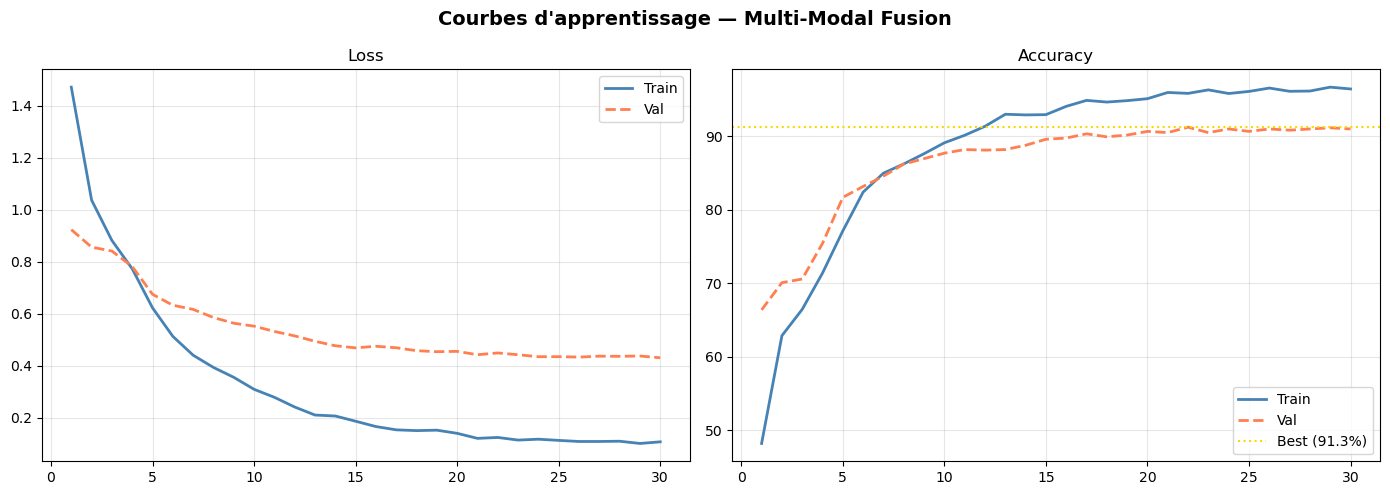

In [26]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'apprentissage — Multi-Modal Fusion", fontsize=14, fontweight='bold')
axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='coral', lw=2, linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train', color='steelblue', lw=2)
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   color='coral', lw=2, linestyle='--')
axes[1].axhline(best_val_acc*100, color='gold', lw=1.5, linestyle=':', label=f'Best ({best_val_acc*100:.1f}%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/learning_curves_fusion.png', dpi=150)
plt.show()

## 3.8 Évaluation sur le jeu de test

In [27]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

@torch.no_grad()
def get_predictions(model, loader):
    all_preds, all_labels = [], []
    for vf, caps, lens, labels in loader:
        logits = model(vf.to(DEVICE), caps.to(DEVICE), lens)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

y_pred, y_true = get_predictions(model, test_loader)
test_acc = accuracy_score(y_true, y_pred)
print(f'Test Accuracy : {test_acc*100:.2f}%\n')
print(classification_report(y_true, y_pred, target_names=label_list, zero_division=0))

Test Accuracy : 90.12%

              precision    recall  f1-score   support

       child       0.99      0.99      0.99       377
         dog       0.99      0.99      0.99       290
       other       0.90      0.78      0.84       324
     outdoor       0.65      0.73      0.69        51
       sport       0.71      0.80      0.75       121
       water       0.66      0.88      0.76        51

    accuracy                           0.90      1214
   macro avg       0.82      0.86      0.83      1214
weighted avg       0.91      0.90      0.90      1214



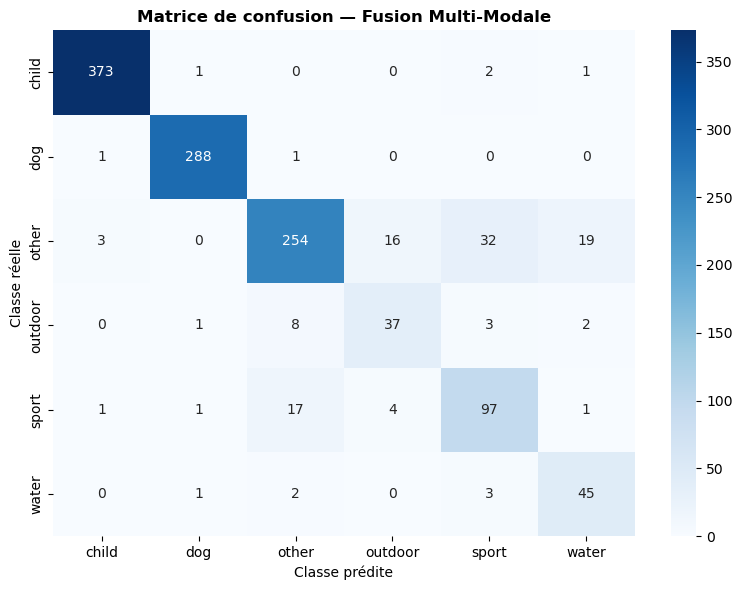

In [28]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list, ax=ax)
ax.set_xlabel('Classe prédite'); ax.set_ylabel('Classe réelle')
ax.set_title('Matrice de confusion — Fusion Multi-Modale', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_fusion.png', dpi=150)
plt.show()

## 3.9 Comparaison unimodal vs multi-modal

In [29]:
class VisualOnlyModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(VISUAL_DIM, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, num_classes))
    def forward(self, vf, caps, lens): return self.head(vf)

class TextOnlyModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes):
        super().__init__()
        self.encoder = TextEncoder(embedding_matrix, hidden_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim*2, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, num_classes))
    def forward(self, vf, caps, lens): return self.head(self.encoder(caps, lens))

def quick_train(model, n_epochs=20):
    opt  = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    for _ in range(n_epochs):
        model.train()
        for vf, caps, lens, labs in train_loader:
            vf, caps, labs = vf.to(DEVICE), caps.to(DEVICE), labs.to(DEVICE)
            opt.zero_grad(); loss = crit(model(vf, caps, lens), labs); loss.backward(); opt.step()
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for vf, caps, lens, labs in test_loader:
            preds = model(vf.to(DEVICE), caps.to(DEVICE), lens).argmax(1)
            correct += (preds == labs.to(DEVICE)).sum().item(); total += labs.size(0)
    return correct / total

print('Entraînement CNN seul...')
acc_visual = quick_train(VisualOnlyModel(NUM_CLASSES).to(DEVICE))
print(f'  Visuel seul  : {acc_visual*100:.2f}%')
print('Entraînement BiLSTM seul...')
acc_text = quick_train(TextOnlyModel(emb_matrix, HIDDEN_DIM, NUM_CLASSES).to(DEVICE))
print(f'  Texte seul   : {acc_text*100:.2f}%')
print(f'  Multi-modal  : {test_acc*100:.2f}%')

Entraînement CNN seul...
  Visuel seul  : 70.10%
Entraînement BiLSTM seul...
  Texte seul   : 95.63%
  Multi-modal  : 90.12%


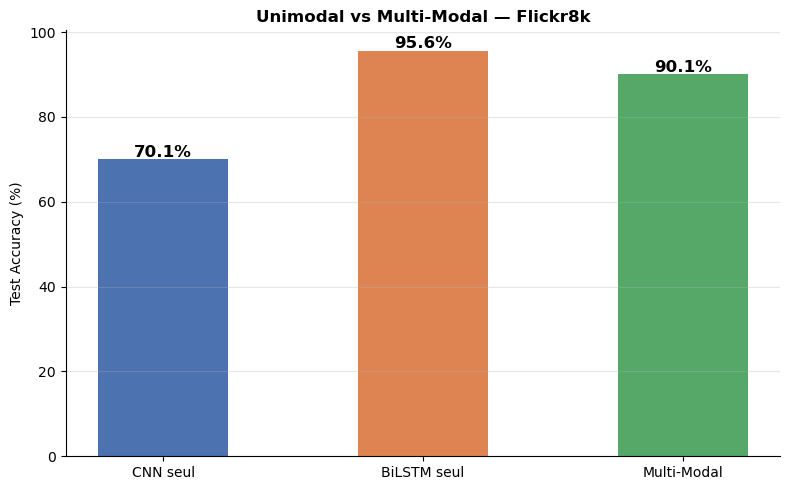

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['CNN seul', 'BiLSTM seul', 'Multi-Modal'],
              [acc_visual*100, acc_text*100, test_acc*100],
              color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
for bar, acc in zip(bars, [acc_visual*100, acc_text*100, test_acc*100]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy (%)'); ax.set_title('Unimodal vs Multi-Modal — Flickr8k', fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/figures/comparison_unimodal_multimodal.png', dpi=150)
plt.show()

## 3.10 Résumé

In [31]:
print('=' * 55)
print('  RÉSUMÉ — STEP 3 : MULTI-MODAL FUSION')
print('=' * 55)
print(f'  Branche visuelle    : ResNet50 pré-extrait → {VISUAL_DIM}-d')
print(f'  Branche textuelle   : GloVe({EMBED_DIM}) + BiLSTM → {TEXT_DIM}-d')
print(f'  Dimension fusionnée : {FUSED_DIM}-d')
print(f'  Classes             : {label_list}')
print('-' * 55)
print(f'  CNN seul   : {acc_visual*100:.2f}%')
print(f'  LSTM seul  : {acc_text*100:.2f}%')
print(f'  Multi-modal: {test_acc*100:.2f}%')
print(f'  Gain/CNN   : +{(test_acc-acc_visual)*100:.2f}%')
print(f'  Gain/LSTM  : {(test_acc-acc_text)*100:+.2f}%')
print('=' * 55)
print('\nStep 3 terminé ✓')

  RÉSUMÉ — STEP 3 : MULTI-MODAL FUSION
  Branche visuelle    : ResNet50 pré-extrait → 2048-d
  Branche textuelle   : GloVe(200) + BiLSTM → 512-d
  Dimension fusionnée : 2560-d
  Classes             : ['child', 'dog', 'other', 'outdoor', 'sport', 'water']
-------------------------------------------------------
  CNN seul   : 70.10%
  LSTM seul  : 95.63%
  Multi-modal: 90.12%
  Gain/CNN   : +20.02%
  Gain/LSTM  : -5.52%

Step 3 terminé ✓


---
# Step 4 — Model Tuning & Optimization

**Problèmes à traiter** :
1. Overfitting (écart train/val)
2. Hyperparamètres non optimisés

**Pipeline** : Early Stopping → Random Search → Meilleur modèle → Évaluation finale

## 4.1 Early Stopping

Stoppe l'entraînement si la val loss ne s'améliore plus pendant `patience` epochs.

In [32]:
class EarlyStopping:
    def __init__(self, patience=5, delta=1e-4, path='../models/checkpoints/best_tuned.pt'):
        self.patience  = patience
        self.delta     = delta
        self.path      = path
        self.counter   = 0
        self.best_loss = float('inf')
        self.stop      = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

print('EarlyStopping defini')

EarlyStopping defini


## 4.2 Random Search sur les hyperparamètres

On explore dropout, learning rate et architecture des couches FC.

In [33]:
import random, itertools

SEARCH_SPACE = {
    'dropout'  : [0.3, 0.4, 0.5],
    'lr'       : [5e-4, 1e-4, 5e-5],
    'fc_hidden': [[512, 256], [1024, 512], [512]],
}

keys, values = list(SEARCH_SPACE.keys()), list(SEARCH_SPACE.values())
all_configs = [dict(zip(keys, c)) for c in itertools.product(*values)]
random.seed(SEED)
configs = random.sample(all_configs, min(9, len(all_configs)))

print(f'{len(configs)} configurations a tester :')
for i, c in enumerate(configs):
    print(f'  [{i+1}] dropout={c["dropout"]} lr={c["lr"]} fc={c["fc_hidden"]}')

9 configurations a tester :
  [1] dropout=0.5 lr=0.0005 fc=[512]
  [2] dropout=0.3 lr=0.0001 fc=[512, 256]
  [3] dropout=0.3 lr=0.0005 fc=[512, 256]
  [4] dropout=0.5 lr=0.0001 fc=[512]
  [5] dropout=0.3 lr=5e-05 fc=[512]
  [6] dropout=0.3 lr=5e-05 fc=[1024, 512]
  [7] dropout=0.5 lr=0.0001 fc=[512, 256]
  [8] dropout=0.3 lr=0.0001 fc=[1024, 512]
  [9] dropout=0.5 lr=5e-05 fc=[1024, 512]


In [34]:
search_results = []

for i, cfg in enumerate(configs):
    m = MultiModalFusionModel(
        embedding_matrix=emb_matrix, hidden_dim=HIDDEN_DIM,
        fc_hidden=cfg['fc_hidden'], num_classes=NUM_CLASSES, dropout=cfg['dropout'],
    ).to(DEVICE)
    opt  = optim.AdamW(m.parameters(), lr=cfg['lr'], weight_decay=WEIGHT_DECAY)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    es   = EarlyStopping(patience=3, path=f'../models/checkpoints/trial_{i+1}.pt')
    best_val = 0.0
    for epoch in range(10):
        m.train()
        for vf, caps, lens, labs in train_loader:
            vf, caps, labs = vf.to(DEVICE), caps.to(DEVICE), labs.to(DEVICE)
            opt.zero_grad(); loss = crit(m(vf, caps, lens), labs); loss.backward(); opt.step()
        val_loss, val_acc = evaluate(m, val_loader, crit)
        es(val_loss, m); best_val = max(best_val, val_acc)
        if es.stop: break
    search_results.append({**cfg, 'val_acc': best_val, 'stopped_at': epoch+1})
    print(f'[{i+1}/{len(configs)}] dropout={cfg["dropout"]} lr={cfg["lr"]} fc={cfg["fc_hidden"]} '
          f'-> val_acc={best_val*100:.2f}% (epoch {epoch+1})')

best_cfg = max(search_results, key=lambda x: x['val_acc'])
print(f'\nMeilleure config : {best_cfg}')

[1/9] dropout=0.5 lr=0.0005 fc=[512] -> val_acc=96.95% (epoch 10)
[2/9] dropout=0.3 lr=0.0001 fc=[512, 256] -> val_acc=95.22% (epoch 10)
[3/9] dropout=0.3 lr=0.0005 fc=[512, 256] -> val_acc=97.36% (epoch 7)
[4/9] dropout=0.5 lr=0.0001 fc=[512] -> val_acc=94.98% (epoch 10)
[5/9] dropout=0.3 lr=5e-05 fc=[512] -> val_acc=95.22% (epoch 10)
[6/9] dropout=0.3 lr=5e-05 fc=[1024, 512] -> val_acc=94.40% (epoch 10)
[7/9] dropout=0.5 lr=0.0001 fc=[512, 256] -> val_acc=91.93% (epoch 10)
[8/9] dropout=0.3 lr=0.0001 fc=[1024, 512] -> val_acc=96.54% (epoch 10)
[9/9] dropout=0.5 lr=5e-05 fc=[1024, 512] -> val_acc=85.83% (epoch 10)

Meilleure config : {'dropout': 0.3, 'lr': 0.0005, 'fc_hidden': [512, 256], 'val_acc': 0.9736408566721582, 'stopped_at': 7}


## 4.3 Entraînement du meilleur modèle

Réentraînement complet avec la meilleure config + early stopping (patience=7).

In [35]:
best_model = MultiModalFusionModel(
    embedding_matrix=emb_matrix, hidden_dim=HIDDEN_DIM,
    fc_hidden=best_cfg['fc_hidden'], num_classes=NUM_CLASSES, dropout=best_cfg['dropout'],
).to(DEVICE)

optimizer_tuned = optim.AdamW(best_model.parameters(), lr=best_cfg['lr'], weight_decay=WEIGHT_DECAY)
scheduler_tuned = optim.lr_scheduler.CosineAnnealingLR(optimizer_tuned, T_max=50, eta_min=1e-6)
criterion_tuned = nn.CrossEntropyLoss(weight=class_weights)
early_stopping  = EarlyStopping(patience=7, path='../models/checkpoints/best_tuned.pt')

history_tuned = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
best_val_tuned = 0.0

print(f"Config : dropout={best_cfg['dropout']} | lr={best_cfg['lr']} | fc={best_cfg['fc_hidden']}")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>7}")
print('-' * 57)

for epoch in range(1, 51):
    train_loss, train_acc = train_one_epoch(best_model, train_loader, criterion_tuned, optimizer_tuned)
    val_loss,   val_acc   = evaluate(best_model, val_loader, criterion_tuned)
    scheduler_tuned.step()
    early_stopping(val_loss, best_model)
    history_tuned['train_loss'].append(train_loss)
    history_tuned['val_loss'].append(val_loss)
    history_tuned['train_acc'].append(train_acc)
    history_tuned['val_acc'].append(val_acc)
    flag = ''
    if val_acc > best_val_tuned: best_val_tuned = val_acc; flag = ' *'
    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | {train_acc*100:>8.2f}% | {val_acc*100:>6.2f}%{flag}")
    if early_stopping.stop: print(f'\nEarly stopping a l epoch {epoch}'); break

print(f'\nMeilleure val accuracy (tuned) : {best_val_tuned*100:.2f}%')

Config : dropout=0.3 | lr=0.0005 | fc=[512, 256]
Epoch | Train Loss | Val Loss | Train Acc | Val Acc
---------------------------------------------------------
    1 |     0.9336 |   0.3798 |    69.77% |  89.04% *
    2 |     0.2229 |   0.2379 |    94.21% |  94.56% *
    3 |     0.0826 |   0.1599 |    97.76% |  98.02% *
    4 |     0.0508 |   0.1470 |    98.80% |  96.79%
    5 |     0.0284 |   0.1232 |    99.21% |  97.20%
    6 |     0.0275 |   0.1617 |    99.24% |  95.55%
    7 |     0.0280 |   0.1332 |    99.33% |  97.69%
    8 |     0.0279 |   0.1395 |    99.56% |  97.36%
    9 |     0.0218 |   0.1458 |    99.49% |  98.11% *
   10 |     0.0116 |   0.1134 |    99.72% |  98.19% *
   11 |     0.0118 |   0.1180 |    99.77% |  98.43% *
   12 |     0.0062 |   0.1313 |    99.86% |  96.62%
   13 |     0.0100 |   0.1305 |    99.75% |  98.11%
   14 |     0.0066 |   0.1325 |    99.89% |  98.11%
   15 |     0.0089 |   0.1360 |    99.75% |  98.35%
   16 |     0.0039 |   0.1221 |    99.93% |  97.9

## 4.4 Courbes d'apprentissage — modèle optimisé

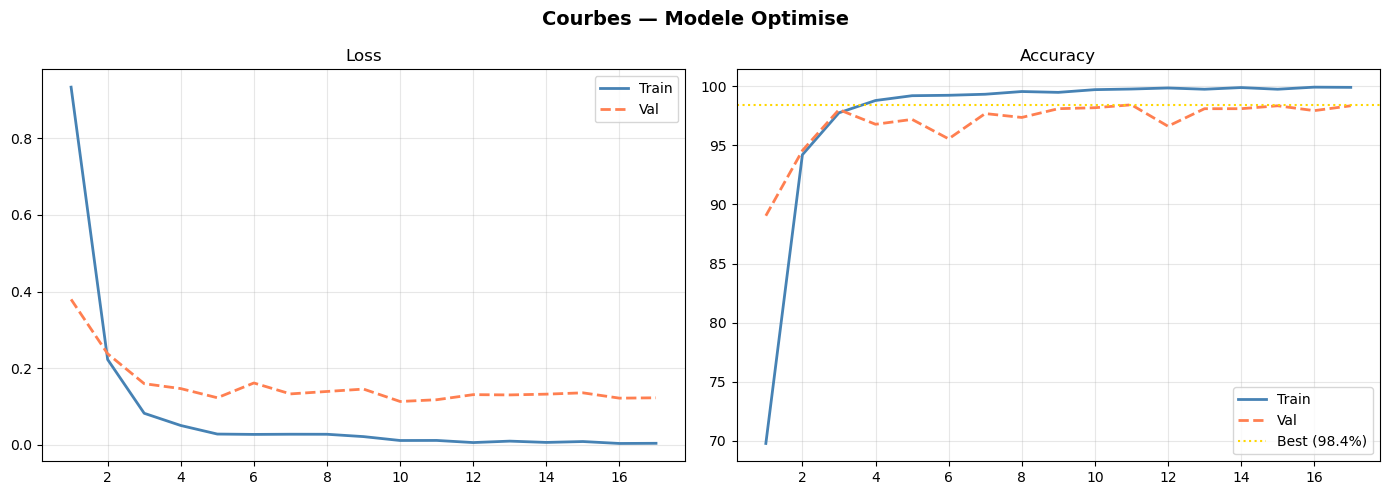

In [36]:
epochs_t = range(1, len(history_tuned['train_loss'])+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes — Modele Optimise", fontsize=14, fontweight='bold')
axes[0].plot(epochs_t, history_tuned['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(epochs_t, history_tuned['val_loss'],   label='Val',   color='coral', lw=2, linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_t, [a*100 for a in history_tuned['train_acc']], label='Train', color='steelblue', lw=2)
axes[1].plot(epochs_t, [a*100 for a in history_tuned['val_acc']],   label='Val',   color='coral', lw=2, linestyle='--')
axes[1].axhline(best_val_tuned*100, color='gold', lw=1.5, linestyle=':', label=f'Best ({best_val_tuned*100:.1f}%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/learning_curves_tuned.png', dpi=150)
plt.show()

## 4.5 Évaluation finale sur le jeu de test

In [37]:
best_model.load_state_dict(torch.load('../models/checkpoints/best_tuned.pt', map_location=DEVICE))
y_pred_tuned, y_true_tuned = get_predictions(best_model, test_loader)
test_acc_tuned = accuracy_score(y_true_tuned, y_pred_tuned)
print(f'Test Accuracy — modele de base  : {test_acc*100:.2f}%')
print(f'Test Accuracy — modele optimise : {test_acc_tuned*100:.2f}%')
print(f'Gain                            : {(test_acc_tuned-test_acc)*100:+.2f}%\n')
print(classification_report(y_true_tuned, y_pred_tuned, target_names=label_list, zero_division=0))

Test Accuracy — modele de base  : 90.12%
Test Accuracy — modele optimise : 98.02%
Gain                            : +7.91%

              precision    recall  f1-score   support

       child       0.99      1.00      1.00       377
         dog       1.00      0.99      1.00       290
       other       0.97      0.97      0.97       324
     outdoor       0.92      0.90      0.91        51
       sport       0.97      0.95      0.96       121
       water       0.91      0.96      0.93        51

    accuracy                           0.98      1214
   macro avg       0.96      0.96      0.96      1214
weighted avg       0.98      0.98      0.98      1214



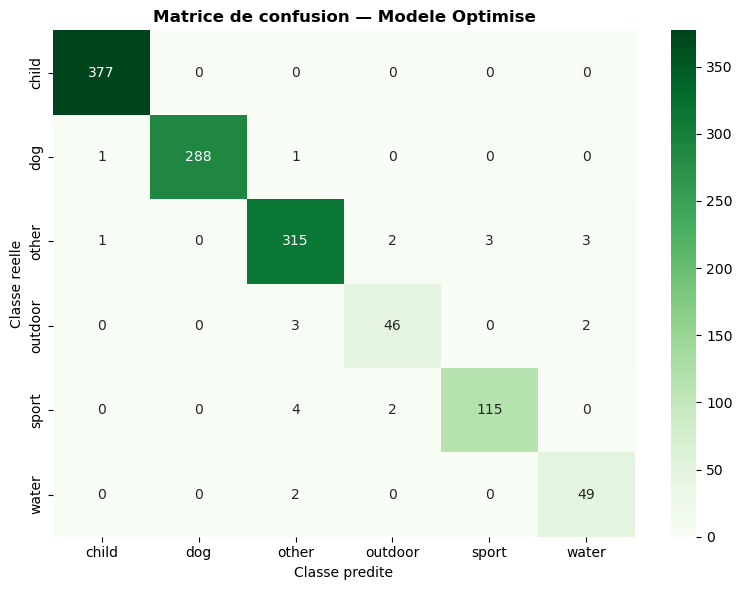

In [38]:
cm_tuned = confusion_matrix(y_true_tuned, y_pred_tuned)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_list, yticklabels=label_list, ax=ax)
ax.set_xlabel('Classe predite'); ax.set_ylabel('Classe reelle')
ax.set_title('Matrice de confusion — Modele Optimise', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_tuned.png', dpi=150)
plt.show()

## 4.6 Analyse des erreurs

Visualisation de quelques exemples mal classifiés.

Erreurs : 24 / 1214 (2.0%)


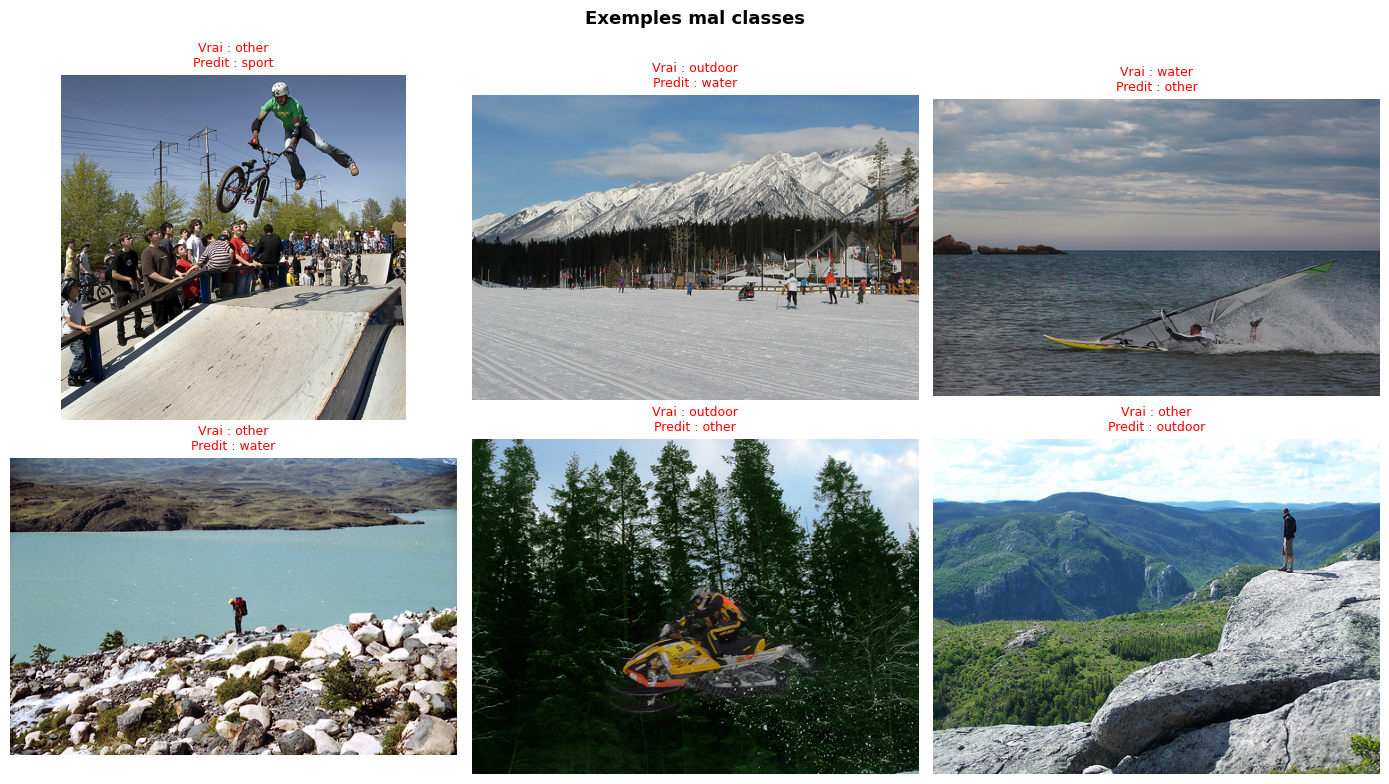

In [39]:
errors_idx = np.where(y_pred_tuned != y_true_tuned)[0]
print(f'Erreurs : {len(errors_idx)} / {len(y_true_tuned)} ({len(errors_idx)/len(y_true_tuned)*100:.1f}%)')

df_test_reset = df_test.reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Exemples mal classes', fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flatten(), errors_idx[:6]):
    row  = df_test_reset.iloc[idx]
    img  = Image.open(row['path']).convert('RGB')
    pred = idx2label[y_pred_tuned[idx]]
    true = idx2label[y_true_tuned[idx]]
    ax.imshow(img)
    ax.set_title(f'Vrai : {true}\nPredit : {pred}', fontsize=9, color='red')
    ax.set_xlabel(row['caption'][:55]+'...', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results/figures/error_analysis.png', dpi=150)
plt.show()

## 4.7 Résumé final

In [40]:
print('=' * 60)
print('  RESUME FINAL — MULTI-MODAL CLASSIFICATION (Flickr8k)')
print('=' * 60)
print(f'  Branche visuelle     : ResNet50 pre-extrait -> {VISUAL_DIM}-d')
print(f'  Branche textuelle    : GloVe({EMBED_DIM}) + BiLSTM -> {TEXT_DIM}-d')
print(f'  Dimension fusionnee  : {FUSED_DIM}-d')
print(f'  Classes              : {label_list}')
print('-' * 60)
print(f'  CNN seul             : {acc_visual*100:.2f}%')
print(f'  BiLSTM seul          : {acc_text*100:.2f}%')
print(f'  Multi-modal (Step 3) : {test_acc*100:.2f}%')
print(f'  Multi-modal (tuned)  : {test_acc_tuned*100:.2f}%  <- meilleur modele')
print(f'  Gain total / CNN     : +{(test_acc_tuned-acc_visual)*100:.2f}%')
print('-' * 60)
print(f'  Meilleure config     : dropout={best_cfg["dropout"]} | lr={best_cfg["lr"]} | fc={best_cfg["fc_hidden"]}')
print(f'  Early stopping       : patience=7')
print(f'  Loss ponderee        : oui')
print('=' * 60)
print('\nStep 4 termine - Projet complet')

  RESUME FINAL — MULTI-MODAL CLASSIFICATION (Flickr8k)
  Branche visuelle     : ResNet50 pre-extrait -> 2048-d
  Branche textuelle    : GloVe(200) + BiLSTM -> 512-d
  Dimension fusionnee  : 2560-d
  Classes              : ['child', 'dog', 'other', 'outdoor', 'sport', 'water']
------------------------------------------------------------
  CNN seul             : 70.10%
  BiLSTM seul          : 95.63%
  Multi-modal (Step 3) : 90.12%
  Multi-modal (tuned)  : 98.02%  <- meilleur modele
  Gain total / CNN     : +27.92%
------------------------------------------------------------
  Meilleure config     : dropout=0.3 | lr=0.0005 | fc=[512, 256]
  Early stopping       : patience=7
  Loss ponderee        : oui

Step 4 termine - Projet complet
